<a href="https://colab.research.google.com/github/SaraBSalazar/courses/blob/main/BIOMICS_variation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Workshop Notebook: BIOMICS variation
Target Study: Warfarin sensitivity in Angiopoietin-1 receptor (TEK)

Tools: UniProt, ProtVar, Deep Mutational Scanning (DMS)

Welcome to the hands-on section of the variation part of the BIOMICS workshop. In this notebook, we will bridge computational predictions with empirical genome engineering:

Query EBI REST APIs to extract functional domain data and variant annotations for human TEK.

Process & Remap Empirical Readouts from a synthetic multiplexed drug-selection assay to identify sensitive residues.

In [1]:
# ==============================================================================
# CELL 1: DEPENDENCIES & SETUP
# Run this cell to load libraries and configure visualisation defaults.
# ==============================================================================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set publication-ready plot parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Dependencies successfully loaded!")

Dependencies successfully loaded!


Module 1: Target Selection & API Integration (~10 mins)
Before designing physical genome edits, we need to gather biological context about our target gene: TEK (UniProt ID: Q02763).

In this step, we programmatically query:

UniProt REST API: To locate the kinase domain, catalytic residues, and drug-binding sites.

Run the cell below to fetch live annotations.

In [2]:
# ==============================================================================
# CELL 2: PROGRAMMATIC TARGET DISCOVERY VIA UniProt REST API
# ==============================================================================
UNIPROT_ACCESSION = "Q02763"

print(f"Fetching UniProt annotations for accession: {UNIPROT_ACCESSION}...\n")

# Query UniProt REST API for functional features
uniprot_url = f"https://rest.uniprot.org/uniprotkb/{UNIPROT_ACCESSION}.json"
response = requests.get(uniprot_url)

if response.status_code == 200:
    uniprot_data = response.json()
    features = uniprot_data.get("features", [])

    key_features = []
    for f in features:
        if f["type"] in ["Binding site", "Active site", "Domain", "Mutagenesis"]:
            key_features.append({
                "Type": f["type"],
                "Start": f["location"]["start"]["value"],
                "End": f["location"]["end"]["value"],
                "Description": f.get("description", "N/A")
            })

    df_features = pd.DataFrame(key_features)
    print("--- UniProt Functional Features (Residues 500–1000) ---")
    print(df_features[df_features["Start"].between(700, 1000)].head(10).to_string(index=False))
else:
    print(f"Failed to fetch UniProt data (HTTP Status: {response.status_code})")



Fetching UniProt annotations for accession: Q02763...

--- UniProt Functional Features (Residues 500–1000) ---
        Type  Start  End              Description
      Domain    824 1096           Protein kinase
 Active site    964  964          Proton acceptor
Binding site    830  838                         
Binding site    855  855                         
 Mutagenesis    855  855 Loss of kinase activity.


Module 2: Empirical NGS Readout Analysis & Heatmap Visualization (~10 mins). After running the saturation mutagenesis library through a cell selection assay under drug treatment (Warfarin vs control), high-throughput sequencing provides variant read counts. Here we: Process pre- and post-selection Next-Generation Sequencing (NGS) count data across residues 890–920.Calculate the Log2 Fold Change ($\text{Log}_2\text{FC}$) to quantify variant enrichment or depletion. Map these fitness scores to reveal key resistance hotspots.

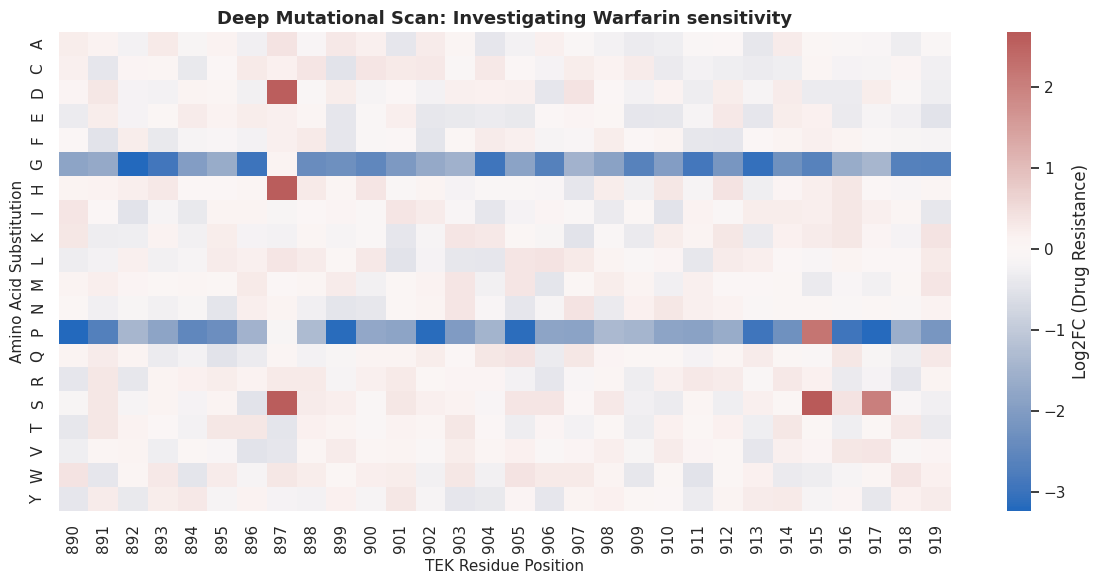


--- Top Enriched Resistance Variants ---
p.Res915S | Log2FC: 2.67
p.Res897H | Log2FC: 2.62
p.Res897S | Log2FC: 2.58
p.Res897D | Log2FC: 2.58
p.Res915P | Log2FC: 2.20


In [3]:
# ==============================================================================
# CELL 3: READOUT ANALYSIS & FUNCTIONAL RESISTANCE MAPPING
# ==============================================================================

# 1. Simulate NGS read count data for deep mutational scan (Residues 890–920)
np.random.seed(42)
residues = list(range(890, 920))
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

data = []
for res in residues:
    for aa in amino_acids:
        base_count_ctrl = np.random.randint(500, 1500)

        # Simulate enrichment under drug pressure for known resistance mutations
        if (res == 897 and aa == 'D') or (res == 897 and aa == 'H') or (res == 897 and aa == 'S') or (res == 915 and aa == 'S') or (res == 915 and aa == 'P') or (res == 917 and aa == 'S'):
            base_count_treat = base_count_ctrl * np.random.uniform(4.0, 8.0)
        # Structural disruptors (e.g., Proline insertion) get depleted
        elif aa in ['P', 'G'] and res != 897:
            base_count_treat = base_count_ctrl * np.random.uniform(0.1, 0.4)
        else:
            base_count_treat = base_count_ctrl * np.random.uniform(0.7, 1.3)

        data.append({
            "Residue": res,
            "AminoAcid": aa,
            "Control_Count": int(base_count_ctrl),
            "Treated_Count": int(base_count_treat)
        })

df_dms = pd.DataFrame(data)

# 2. Compute Log2 Fold Change (Fitness Score)
df_dms["Log2FC"] = np.log2((df_dms["Treated_Count"] + 1) / (df_dms["Control_Count"] + 1))

# Pivot into matrix for visualization
pivot_df = df_dms.pivot(index="AminoAcid", columns="Residue", values="Log2FC")

# 3. Plot Functional Fitness Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_df, cmap="vlag", center=0, cbar_kws={'label': 'Log2FC (Drug Resistance)'}, ax=ax)
ax.set_title("Deep Mutational Scan: Investigating Warfarin sensitivity", fontsize=13, fontweight='bold')
ax.set_xlabel("TEK Residue Position", fontsize=11)
ax.set_ylabel("Amino Acid Substitution", fontsize=11)
plt.tight_layout()
plt.show()

# Extract top resistant mutations
top_resistant = df_dms.sort_values(by="Log2FC", ascending=False).head(5)
print("\n--- Top Enriched Resistance Variants ---")
for _, row in top_resistant.iterrows():
    print(f"p.Res{row['Residue']}{row['AminoAcid']} | Log2FC: {row['Log2FC']:.2f}")

Module 3: Once we have identified key changes experimentally we can Assess the bilogical context via ProtVar REST API. One key feature is extracted below but you can edit the code to filter for different annotation features.Using the links we can then further analyse the position in protein structre via the ProtVar UI.

In [4]:
# ==============================================================================
# CELL 4: PROGRAMMATIC POSITION ANALYSIS VIA ProtVar REST API
# ==============================================================================
UNIPROT_ACCESSION = "Q02763"
POSITION = "897"
REFERENCE = "Y"
VARIANT = "H"

print(f"Fetching ProtVar annotations for accession: {UNIPROT_ACCESSION},{POSITION},{VARIANT}\n")

# 1. Query UniProt REST API for functional features
protvar_url = f"https://www.ebi.ac.uk/ProtVar/api/function/{UNIPROT_ACCESSION}/{POSITION}?variantAA={VARIANT}.json"
response = requests.get(protvar_url)
print ("The json object is here:\n")
print (protvar_url)


response = requests.get(protvar_url)
data = response.json()

# Features extracted from the API payload
features = {
    "protein": data.get("accession"),
    "position": data.get("position"),
    "Conservation": data.get("conservScore", {}).get("score")
}

print(json.dumps(features, indent=2))

UI_link = f"https://www.ebi.ac.uk/ProtVar/search?q={UNIPROT_ACCESSION}+{POSITION}+{REFERENCE}+{VARIANT}&annotation=fun"
print (UI_link)

Fetching ProtVar annotations for accession: Q02763,897,H

The json object is here:

https://www.ebi.ac.uk/ProtVar/api/function/Q02763/897?variantAA=H.json
{
  "protein": "Q02763",
  "position": 897,
  "Conservation": 0.473
}
https://www.ebi.ac.uk/ProtVar/search?q=Q02763+897+Y+H&annotation=fun


Workshop Summary & Key Takeaways: Computational tools like UniProt and ProtVar pinpoint essential residues, but high-throughput experimental assays (DMS/MAVEs) are needed to measure true biological impact.
Data Remapping: Mapping NGS selection scores back to protein structures validates known clinical drivers (e.g., 897, 915, 917) and highlights novel candidate resistance mechanisms.